In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

sys.path.insert(0, os.path.abspath('results/'))

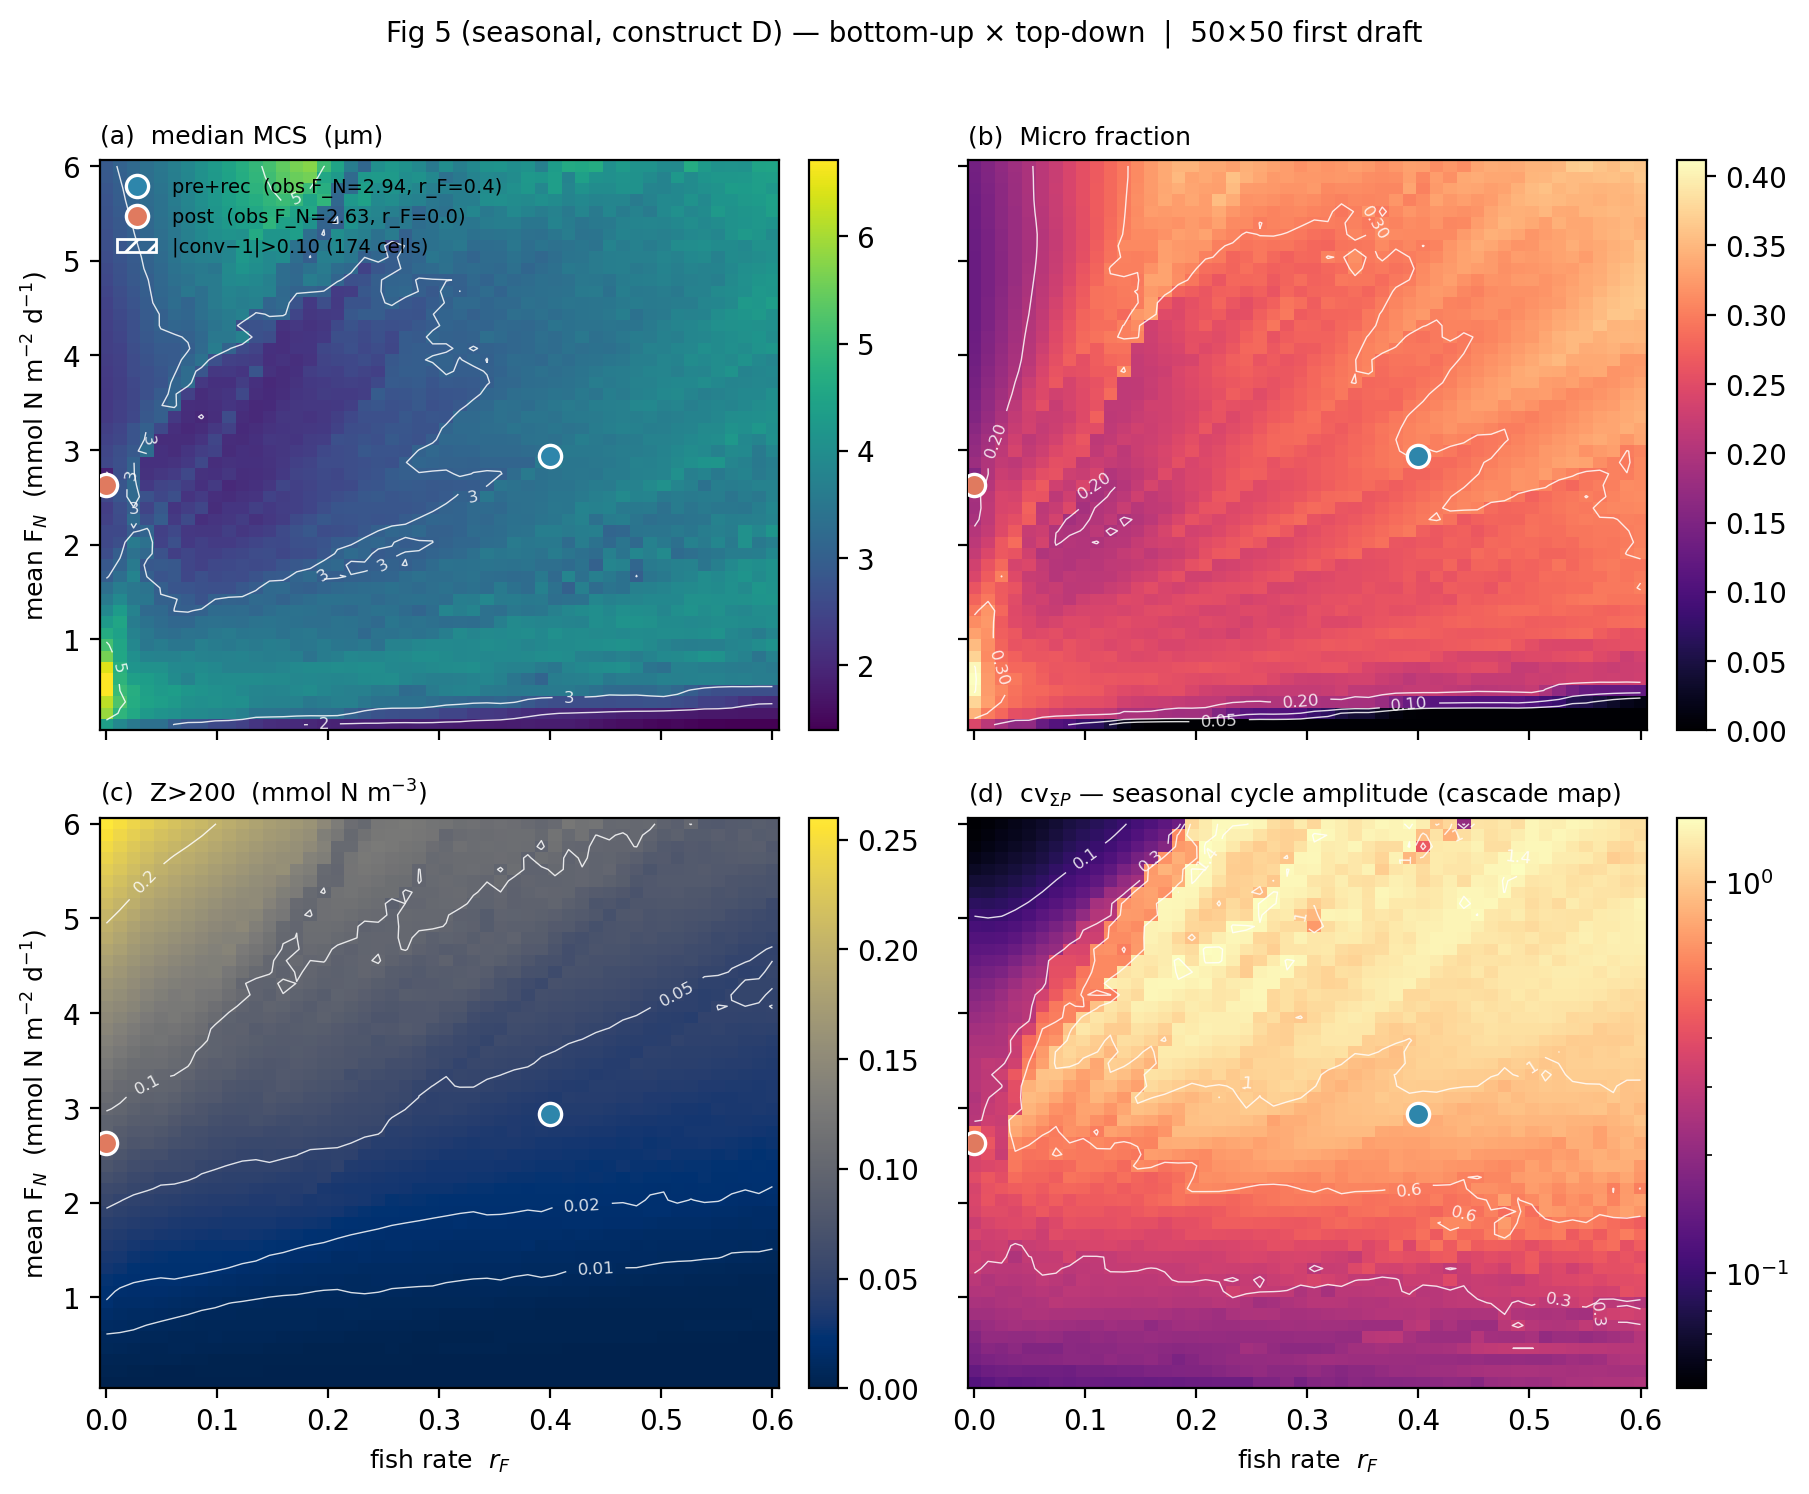


=== Operating-point values (nearest grid) ===

pre+rec  ≈  (F_N=2.99, r_F=0.40):
   MCS_med  =  3.51 µm
   MCS_mean =  5.89 µm
   Pico     = 0.48
   Nano     = 0.23
   Micro    = 0.30
   ΣP       =  0.71 mmol N m⁻³
   Z>200    = 0.0386 mmol N m⁻³
   Z>500    = 0.0077 mmol N m⁻³
   N        = 1.254 mmol N m⁻³
   cv_sumP  = 0.926
   |conv−1| = 0.000 (drift)

post  ≈  (F_N=2.63, r_F=0.00):
   MCS_med  =  2.46 µm
   MCS_mean =  3.06 µm
   Pico     = 0.55
   Nano     = 0.27
   Micro    = 0.18
   ΣP       =  0.54 mmol N m⁻³
   Z>200    = 0.0865 mmol N m⁻³
   Z>500    = 0.0336 mmol N m⁻³
   N        = 1.478 mmol N m⁻³
   cv_sumP  = 0.366
   |conv−1| = 0.001 (drift)

=== Pre/Post ratios (model vs obs) ===
  mcs_med :  model 1.42   obs 2.34
  micro   :  model 1.61   obs 2.33
  Z200    :  model 0.45   obs 0.66

=== Surface summary ===
  MCS_med  range: 1.39–6.71 µm
  cv_sumP  range: 0.051–1.458
  Z>200    range: 0.0000–0.2598
  Micro    range: 0.00–0.41
  cells with cv_sumP > 1.0 (high-cycle re

In [1]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

ds = xr.open_dataset('results/fig5_seasonal_scan_50x50_2026-06-25.nc')
mean_FN = ds['mean_FN'].values
R_F     = ds['rF'].values

# convergence mask (interannual drift flag) — for hatching
nonconv = np.abs(ds['mcs_conv'].values - 1.0) > 0.10

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'),
       ('post',    2.63, 0.0, '#E07A5F')]

panels = [
    ('(a)  median MCS  (µm)',            ds['mcs_med'].values, 'viridis',
     [2, 3, 5, 8, 12],                   '%g',   None),
    ('(b)  Micro fraction',              ds['micro'].values,   'magma',
     [0.05, 0.10, 0.20, 0.30, 0.40],     '%.2f', None),
    ('(c)  Z>200  (mmol N m$^{-3}$)',    ds['Z200'].values,    'cividis',
     [0.01, 0.02, 0.05, 0.10, 0.20],     '%.2g', None),
    ('(d)  cv$_{\\Sigma P}$ — seasonal cycle amplitude (cascade map)',
                                         ds['cv_sumP'].values, 'magma',
     [0.10, 0.30, 0.60, 1.00, 1.40],     '%.2g',
     LogNorm(vmin=max(float(np.nanmin(ds['cv_sumP'].values)), 1e-3),
             vmax=float(np.nanmax(ds['cv_sumP'].values)))),
]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.6), sharex=True, sharey=True)
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(R_F, mean_FN, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(R_F, mean_FN, surf, levels=lvls, colors='white', linewidths=0.5, alpha=0.85)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    # hatch non-converged cells
    ax.pcolor(R_F, mean_FN, np.where(nonconv, 1, np.nan), shading='nearest',
              hatch='///', alpha=0, edgecolor='white', linewidth=0.0)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl, zorder=5)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)

# legend with the hatching marker once
nonconv_patch = Patch(facecolor='none', edgecolor='white', hatch='///',
                      label=f'|conv−1|>0.10 ({int(nonconv.sum())} cells)')
axes[0,0].legend(handles=[
    plt.Line2D([0],[0], marker='o', ms=8, color='#2E86AB', mec='white', mew=1.2,
               linestyle='', label='pre+rec  (obs F_N=2.94, r_F=0.4)'),
    plt.Line2D([0],[0], marker='o', ms=8, color='#E07A5F', mec='white', mew=1.2,
               linestyle='', label='post  (obs F_N=2.63, r_F=0.0)'),
    nonconv_patch,
], fontsize=7, frameon=False, loc='upper left')

for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (seasonal, construct D) — bottom-up × top-down  |  50×50 first draft',
             fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# === numerical read-off ===========================================
def _near(a, v): return int(np.argmin(np.abs(a - v)))
print("\n=== Operating-point values (nearest grid) ===")
metrics = [('MCS_med', 'mcs_med', '%5.2f µm'),
           ('MCS_mean','mcs_mean','%5.2f µm'),
           ('Pico',    'pico',    '%.2f'),
           ('Nano',    'nano',    '%.2f'),
           ('Micro',   'micro',   '%.2f'),
           ('ΣP',      'sumP',    '%5.2f mmol N m⁻³'),
           ('Z>200',   'Z200',    '%.4f mmol N m⁻³'),
           ('Z>500',   'Z500',    '%.4f mmol N m⁻³'),
           ('N',       'N',       '%.3f mmol N m⁻³'),
           ('cv_sumP', 'cv_sumP', '%.3f'),
           ('|conv−1|','mcs_conv','%.3f (drift)')]
for lbl, fn, rf, _ in OPS:
    i, j = _near(mean_FN, fn), _near(R_F, rf)
    print(f"\n{lbl}  ≈  (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}):")
    for label, key, fmt in metrics:
        v = float(ds[key].values[i, j])
        if key == 'mcs_conv': v = abs(v - 1.0)
        print(f"   {label:8s} = " + (fmt % v))

print("\n=== Pre/Post ratios (model vs obs) ===")
i_pre, j_pre = _near(mean_FN, 2.94), _near(R_F, 0.4)
i_pos, j_pos = _near(mean_FN, 2.63), _near(R_F, 0.0)
obs_ratios = dict(mcs_med=7.66/3.28, micro=0.42/0.18, Z200=0.057/0.087)
for key, obs in obs_ratios.items():
    mdl = float(ds[key].values[i_pre, j_pre] / max(ds[key].values[i_pos, j_pos], 1e-12))
    print(f"  {key:8s}:  model {mdl:.2f}   obs {obs:.2f}")

print(f"\n=== Surface summary ===")
print(f"  MCS_med  range: {float(ds['mcs_med'].min()):.2f}–{float(ds['mcs_med'].max()):.2f} µm")
print(f"  cv_sumP  range: {float(ds['cv_sumP'].min()):.3f}–{float(ds['cv_sumP'].max()):.3f}")
print(f"  Z>200    range: {float(ds['Z200'].min()):.4f}–{float(ds['Z200'].max()):.4f}")
print(f"  Micro    range: {float(ds['micro'].min()):.2f}–{float(ds['micro'].max()):.2f}")
print(f"  cells with cv_sumP > 1.0 (high-cycle regime):  "
      f"{int((ds['cv_sumP'] > 1.0).sum())}/{int(ds['cv_sumP'].size)}")
print(f"  cells flagged non-converged (|conv-1|>0.10):   {int(nonconv.sum())}/{int(nonconv.size)}")

In [2]:
import numpy as np

# Four corners of the 2×2 experiment (F_N × fish)
# Diagonals = obs-anchored, off-diagonals = model-supplied counterfactuals
CORNERS = {
    'pre/on  (obs)':      (2.94, 0.4),   # historical pre+rec, fish present
    'pre/off (counter)':  (2.94, 0.0),   # pre F_N, no fish
    'post/on (counter)':  (2.63, 0.4),   # post F_N, fish present
    'post/off (obs)':     (2.63, 0.0),   # historical post, fish absent
}

def _near(a, v): return int(np.argmin(np.abs(a - v)))
def _cell(corner, var):
    fn, rf = CORNERS[corner]
    i, j = _near(ds['mean_FN'].values, fn), _near(ds['rF'].values, rf)
    return float(ds[var].values[i, j])

print("=" * 90)
print("Fig 5 — the 2×2 experiment: F_N × fish at era operating points")
print("=" * 90)
print(f"{'cell':<22}{'F_N':>7}{'r_F':>6}   "
      f"{'MCS_mn':>8}{'MCS_md':>8}{'Micro':>7}{'Z>200':>9}{'cv_ΣP':>8}{'ΣP':>7}")
for cn in CORNERS:
    fn, rf = CORNERS[cn]
    print(f"{cn:<22}{fn:>7.2f}{rf:>6.2f}   "
          f"{_cell(cn,'mcs_mean'):>8.2f}{_cell(cn,'mcs_med'):>8.2f}"
          f"{_cell(cn,'micro'):>7.2f}{_cell(cn,'Z200'):>9.4f}"
          f"{_cell(cn,'cv_sumP'):>8.2f}{_cell(cn,'sumP'):>7.2f}")

# Two-way decomposition
print("\n" + "=" * 90)
print("Symmetric main effects — average of the two 'reach the other diagonal' paths")
print("=" * 90)

OBS = {'mcs_mean': (7.66, 3.28), 'mcs_med': (None, None),
       'micro': (0.42, 0.18), 'Z200': (0.057, 0.087)}

for var, lbl in [('mcs_mean', 'MCS_mean (µm)'),
                 ('mcs_med',  'MCS_med  (µm)'),
                 ('micro',    'Micro fraction'),
                 ('Z200',     'Z>200 (mmol N m⁻³)')]:
    A = _cell('pre/on  (obs)',     var)
    B = _cell('pre/off (counter)', var)
    C = _cell('post/on (counter)', var)
    D = _cell('post/off (obs)',    var)
    total      = A - D                       # full pre→post shift in model
    top_at_pre = A - B                       # fish on→off, holding F_N at pre
    bot_at_off = B - D                       # F_N pre→post, holding fish off
    top_at_post= C - D                       # fish on→off, holding F_N at post
    bot_at_on  = A - C                       # F_N pre→post, holding fish on
    top_main   = 0.5*(top_at_pre + top_at_post)
    bot_main   = 0.5*(bot_at_on  + bot_at_off)
    interact   = total - top_main - bot_main
    obs_total  = (OBS[var][0] - OBS[var][1]) if OBS[var][0] is not None else None

    print(f"\n{lbl}")
    print(f"  cells:  A(pre/on)={A:.3f}  B(pre/off)={B:.3f}  "
          f"C(post/on)={C:.3f}  D(post/off)={D:.3f}")
    print(f"  total Δ (model)  = A − D = {total:+.3f}"
          + (f"   |   obs Δ = {obs_total:+.3f}" if obs_total is not None else ""))
    print(f"  top-down @ pre   = A − B = {top_at_pre:+.3f}     "
          f"top-down @ post  = C − D = {top_at_post:+.3f}")
    print(f"  bottom-up @ off  = B − D = {bot_at_off:+.3f}     "
          f"bottom-up @ on   = A − C = {bot_at_on:+.3f}")
    print(f"  main effects     : top-down = {top_main:+.3f}   "
          f"bottom-up = {bot_main:+.3f}   interaction = {interact:+.3f}")
    if abs(total) > 1e-9:
        print(f"  share of total Δ : top-down = {top_main/total*100:+5.0f}%   "
              f"bottom-up = {bot_main/total*100:+5.0f}%   "
              f"interaction = {interact/total*100:+5.0f}%")

# Counterfactual readings (what nature didn't sample)
print("\n" + "=" * 90)
print("Counterfactual readings — what nature didn't sample")
print("=" * 90)
print("Q1: 'If pre had no fish, what would MCS have looked like?'")
print(f"   pre/off MCS_mean = {_cell('pre/off (counter)', 'mcs_mean'):.2f} µm   "
      f"(historical pre+rec MCS_mean = {_cell('pre/on  (obs)', 'mcs_mean'):.2f},  "
      f"historical post MCS_mean = {_cell('post/off (obs)', 'mcs_mean'):.2f})")
print("   → does pre WITHOUT fish look more like the pre or the post end-member?")
print()
print("Q2: 'If post still had sardines, what would MCS have looked like?'")
print(f"   post/on MCS_mean = {_cell('post/on (counter)', 'mcs_mean'):.2f} µm   "
      f"(same anchors as above)")
print("   → does post WITH fish look more like the pre or the post end-member?")

# Same for Z>200 — the cleanest top-down signature
print()
print("Same logic, Z>200 (the obs's cleanest top-down signature, p=0.000):")
print(f"   pre WITHOUT fish: Z>200 = {_cell('pre/off (counter)', 'Z200'):.4f}   "
      f"(obs pre = {OBS['Z200'][0]:.3f}, obs post = {OBS['Z200'][1]:.3f})")
print(f"   post WITH fish:  Z>200 = {_cell('post/on (counter)', 'Z200'):.4f}")

Fig 5 — the 2×2 experiment: F_N × fish at era operating points
cell                      F_N   r_F     MCS_mn  MCS_md  Micro    Z>200   cv_ΣP     ΣP
pre/on  (obs)            2.94  0.40       5.89    3.51   0.30   0.0386    0.93   0.71
pre/off (counter)        2.94  0.00       2.80    2.50   0.17   0.1011    0.27   0.55
post/on (counter)        2.63  0.40       5.29    3.43   0.28   0.0308    0.75   0.63
post/off (obs)           2.63  0.00       3.06    2.46   0.18   0.0865    0.37   0.54

Symmetric main effects — average of the two 'reach the other diagonal' paths

MCS_mean (µm)
  cells:  A(pre/on)=5.886  B(pre/off)=2.803  C(post/on)=5.294  D(post/off)=3.057
  total Δ (model)  = A − D = +2.829   |   obs Δ = +4.380
  top-down @ pre   = A − B = +3.083     top-down @ post  = C − D = +2.237
  bottom-up @ off  = B − D = -0.255     bottom-up @ on   = A − C = +0.592
  main effects     : top-down = +2.660   bottom-up = +0.169   interaction = -0.000
  share of total Δ : top-down =   +94%   bott

In [ ]:
# RUNNING THE SCAN

In [3]:
import warnings, time as _t, numpy as np
import seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
mean_FN_target = np.linspace(0.1, 6.0, 50)
FN_SCALE = mean_FN_target / base['fn'].mean()
R_F      = np.linspace(0.0, 0.6, 50)
print(f"mean F_N: {mean_FN_target[0]:.2f}–{mean_FN_target[-1]:.2f}  (Δ={mean_FN_target[1]-mean_FN_target[0]:.3f}, n={len(mean_FN_target)})")
print(f"r_F:      {R_F[0]:.3f}–{R_F[-1]:.3f}  (Δ={R_F[1]-R_F[0]:.4f}, n={len(R_F)})")
print(f"tasks:    {len(mean_FN_target)*len(R_F)}\n")
print(f"SEASONAL_SOLVER_KWARGS: {ssh.SEASONAL_SOLVER_KWARGS}")
print(f"(expect tight: atol=1e-9, rtol=1e-6, max_step=1.0, floor=-1e-3)\n")

spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn']*fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO),)
          for fs, rf in combos]

shape = (len(FN_SCALE), len(R_F))
def _e(): return np.full(shape, np.nan)
MCS_med, MCS_mn = _e(), _e()
PICO, NANO, MICRO = _e(), _e(), _e()
SUMP, SUMZ, Z200, Z500 = _e(), _e(), _e(), _e()
NMEAN, PP, EXPORT = _e(), _e(), _e()
CVSP, CVSZ, CONV = _e(), _e(), _e()
MINP, MINZ = _e(), _e()
HASN = np.zeros(shape, dtype=bool)

def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']: return
    m = item['result']
    MCS_med[i,j] = m.get('mcs_med', np.nan); MCS_mn[i,j] = m.get('mcs', np.nan)
    PICO[i,j]  = m.get('pico', np.nan);  NANO[i,j] = m.get('nano', np.nan)
    MICRO[i,j] = m.get('micro', np.nan)
    SUMP[i,j]  = m.get('sumP', np.nan);  SUMZ[i,j] = m.get('sumZ', np.nan)
    Z200[i,j]  = m.get('Z200', np.nan);  Z500[i,j] = m.get('Z500', np.nan)
    NMEAN[i,j] = m.get('N', np.nan)
    PP[i,j]    = m.get('PP', np.nan);    EXPORT[i,j] = m.get('Export', np.nan)
    CVSP[i,j]  = m.get('cv_sumP', np.nan); CVSZ[i,j] = m.get('cv_sumZ', np.nan)
    CONV[i,j]  = m.get('mcs_conv', np.nan)
    MINP[i,j]  = m.get('minP', np.nan);  MINZ[i,j] = m.get('minZ', np.nan)
    HASN[i,j]  = bool(m.get('has_nan', False))

t0 = _t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks,
                   processes=12,                                # see sizing rule
                   maxtasksperchild=1,                          # ← scipy#10070 fix
                   on_result=on_result, tally_flags=['has_nan'],
                   label='fig5_seasonal_50x50')
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min\n")

print(f"trips:           {int(HASN.sum())}/{HASN.size}")
print(f"|conv-1| > 0.10: {int(np.nansum(np.abs(CONV-1) > 0.10))}/{HASN.size}")
print(f"MCS_med range:   {np.nanmin(MCS_med):.2f} – {np.nanmax(MCS_med):.2f} µm")
print(f"cv_sumP range:   {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"Z>200 range:     {np.nanmin(Z200):.4f} – {np.nanmax(Z200):.4f}")
print(f"Micro range:     {np.nanmin(MICRO):.2f} – {np.nanmax(MICRO):.2f}")

import xarray as xr, os
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_seasonal_scan_50x50_2026-06-25.nc')
ds = xr.Dataset(
    data_vars={
        'mcs_med': (('FN_scale','rF'), MCS_med), 'mcs_mean': (('FN_scale','rF'), MCS_mn),
        'pico':    (('FN_scale','rF'), PICO),    'nano':    (('FN_scale','rF'), NANO),
        'micro':   (('FN_scale','rF'), MICRO),
        'sumP':    (('FN_scale','rF'), SUMP),    'sumZ':    (('FN_scale','rF'), SUMZ),
        'Z200':    (('FN_scale','rF'), Z200),    'Z500':    (('FN_scale','rF'), Z500),
        'N':       (('FN_scale','rF'), NMEAN),
        'PP':      (('FN_scale','rF'), PP),      'Export':  (('FN_scale','rF'), EXPORT),
        'cv_sumP': (('FN_scale','rF'), CVSP),    'cv_sumZ': (('FN_scale','rF'), CVSZ),
        'mcs_conv':(('FN_scale','rF'), CONV),
        'minP':    (('FN_scale','rF'), MINP),    'minZ':    (('FN_scale','rF'), MINZ),
        'has_nan': (('FN_scale','rF'), HASN.astype(np.int8)),
        'mean_FN': (('FN_scale',), mean_FN_target),
    },
    coords={'FN_scale': FN_SCALE, 'rF': R_F},
    attrs=dict(
        construct='maranon_ward (Marañón 2013 μ + Ward 2012 K_s)',
        grazing='Dutkiewicz 2020 Type III + omnivory',
        GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
        forcing='seasonal pre+recovery (d_e and T from obs monthly climatology)',
        years=40, spinup=10,
        solver='tight RK45 (atol=1e-9, rtol=1e-6, max_step=1.0)',
        memory='maxtasksperchild=1 (scipy#10070 worker recycling)',
        FN_axis='linspace(0.1, 6.0, 50) mean F_N',
        rF_axis='linspace(0.0, 0.6, 50)',
        created='2026-06-25',
    ),
)
ds.to_netcdf(nc_path)
print(f"\nsaved: {nc_path} ({os.path.getsize(nc_path)/1e3:.1f} KB)")

mean F_N: 0.10–6.00  (Δ=0.120, n=50)
r_F:      0.000–0.600  (Δ=0.0122, n=50)
tasks:    2500

SEASONAL_SOLVER_KWARGS: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
(expect tight: atol=1e-9, rtol=1e-6, max_step=1.0, floor=-1e-3)

--- run_parallel_tasks: 2500 tasks, 12 workers (fig5_seasonal_50x50) ---
     1/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 1636.3m
     2/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 853.2m
     3/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 569.1m
     4/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 427.6m
     5/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 343.2m
     6/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 286.2m
     7/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 245.8m
     8/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 215.1m
     9/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 191.3m
    10/2500 fig5_seasonal_50x

In [7]:
clim, r = ssh.run_one(spec, {**base, 'fn': base['fn']*1.7}, fish_rate=0.0,
                      years=20, spinup=2, mP=0.0015, m_Z=0.1,
                      grazing=GRZ, iv_overrides=IVO,
                      solver_kwargs=SK, return_traj=True)
# look at the last ~365 d before NaN
t = r['t']; ok = ~np.isnan(r['sumP']); t_end = t[ok][-1]
mask = (t >= t_end - 365) & ok
print('crash time (d):', t_end, '  N_min:', np.nanmin(r['N'][mask]),
      '  Z>200 peak:', np.nanmax(r['Z200'][mask]),
      '  minP floor:', np.nanmin(r['minP'][mask]),
      '  sumP peak:', np.nanmax(r['sumP'][mask]))

crash time (d): 7299.999999999999   N_min: 4.748295227268713   Z>200 peak: 0.24331038294059887   minP floor: 0.0   sumP peak: 0.8139728458175906


In [ ]:
import warnings, time, numpy as np, seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}
TRIP = dict(construct=spec, forcing={**base, 'fn': base['fn'] * 0.617},
            fish_rate=0.6, years=20, spinup=2,
            mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO, return_traj=True)

def _try(label, sk):
    t0 = time.perf_counter()
    clim, r = ssh.run_one(**TRIP, solver_kwargs=sk)
    dt = time.perf_counter() - t0
    t = r['t']; sp = r['sumP']; ok = ~np.isnan(sp)
    last_ok = t[ok][-1] if ok.any() else np.nan
    print(f"{label:20s} | wall {dt:5.1f}s | last finite t={last_ok:7.1f} d "
          f"({last_ok/365:5.2f} yr) | has_nan={clim['has_nan']} | "
          f"minP={np.nanmin(r['minP']):+.2e}  minZ={np.nanmin(r['minZ']):+.2e} | "
          f"sumP last={sp[ok][-1] if ok.any() else np.nan:.3f}")
    return clim, r

c_rk, r_rk = _try('RK45 (default)',  {'instability_neg_threshold': -1e-3})
c_bdf, r_bdf = _try('BDF, rtol=1e-4', {'method': 'BDF', 'rtol': 1e-4, 'atol': 1e-6,
                                        'instability_neg_threshold': -1e-3})
c_bdf2, r_bdf2 = _try('BDF, tight',   {'method': 'BDF', 'rtol': 1e-6, 'atol': 1e-9,
                                        'instability_neg_threshold': -1e-3})

In [9]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

# Capture the trip warning text instead of silencing it
TRIPS = []
def _trip_capturing_warner(message, category, filename, lineno, file=None, line=None):
    msg = str(message)
    if 'Instability event' in msg:
        TRIPS.append(msg)
warnings.showwarning = _trip_capturing_warner

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy(); TRIPLOC = {}
trip_log = []   # (fs, rf, trip_msg_or_None)
def on_result(item, done, n):
    k = item['index']
    i, j = divmod(k, len(R_F))
    fs, rf = combos[k]
    if item['ok']:
        m = item['result']
        MCS[i, j]  = m.get('mcs_med', np.nan)
        CONV[i, j] = m.get('mcs_conv', np.nan)
        if m.get('has_nan'):
            # `TRIPS` is appended to in arrival order, not submission order, so we tag this
            # cell as tripped without claiming a specific message-text match
            TRIPLOC[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))
            trip_log.append((float(fs), float(rf), m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')

# Diagnostic summary
trip_cells = sorted(TRIPLOC.items(), key=lambda kv: (kv[1][0], kv[1][1]))
print(f"\nTrips: {len(trip_cells)} / {MCS.size}")
for (i, j), (fs, rf, frac) in trip_cells:
    print(f"  cell (i={i}, j={j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
          f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
print(f"\nRaw trip messages captured ({len(TRIPS)}):")
for m in TRIPS[:10]:
    # extract the "P[15] = -0.0527" / "Z[19] = ..." style locator
    import re
    loc = re.search(r'on\s+([PZ])\[(\d+)\]\s*=\s*([\-\d\.e]+)', m)
    t   = re.search(r't=([\d\.e\+\-]+)', m)
    print(f"  t={t.group(1) if t else '?':>10s}  class={loc.group(1)+'['+loc.group(2)+']' if loc else '?':>8s}  value={loc.group(3) if loc else '?'}")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.0m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.5m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.5m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.0m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.7m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.7m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.5m
  14/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0544. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2786 on P[15] = -0.0349. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=18 | 1.4m ETA 0.2m
  45/49 fig5 | err=0 has_nan=19 | 1.4m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2760 on Z[19] = -0.03. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=20 | 1.4m ETA 0.1m
  47/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.1m
  48/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7100 on P[18] = -0.05. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=21 | 1.5m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=21 | 1.5m ---

Trips: 21 / 49
  cell (i=2, j=3) | F_N×0.833 (mean 2.56) | r_F=0.30 | nan_frac=1.00
  cell (i=2, j=5) | F_N×0.833 (mean 2.56) | r_F=0.50 | nan_frac=1.00
  cell (i=2, j=6) | F_N×0.833 (mean 2.56) | r_F=0.60 | nan_frac=0.84
  cell (i=3, j=4) | F_N×1.050 (mean 3.23) | r_F=0.40 | nan_frac=1.00
  cell (i=3, j=6) | F_N×1.050 (mean 3.23) | r_F=0.60 | nan_frac=0.88
  cell (i=4, j=1) | F_N×1.267 (mean 3.89) | r_F=0.10 | nan_frac=1.00
  cell (i=4, j=2) | F_N×1.267 (mean 3.89) | r_F=0.20 | nan_frac=0.49
  cell (i=4, j=3) | F_N×1.267 (mean 3.89) | r_F=0.30 | nan_frac=0.14
  cell (i=4, j=4) | F_N×1.267 (mean 3.89) | r_F=0.40 | nan_frac=0.88
  cell (i=4, j=5) | F_N×1.267 (mean 3.89) | r_F=0.50 | nan_frac=1.00
  cell (i=5, j=1) | F_N×1.483 (mean 4.56) | r_F=0.10 | nan_frac=0.95
  cell (i=5, j=2) | F_N×1.483 (mean 4.56) | r_F=0.20 | nan_frac=1.00
  cell (i=5, j=3) | F_N×1.483 (mean 4.56) | r_F=0.

In [10]:
SK_NO_FLOOR = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': float('-inf')}

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy(); HASN = MCS.copy()

def on_result_diag(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if item['ok']:
        m = item['result']
        MCS[i,j]  = m.get('mcs_med', np.nan)
        CONV[i,j] = m.get('mcs_conv', np.nan)
        MINP[i,j] = m.get('minP', np.nan)
        MINZ[i,j] = m.get('minZ', np.nan)
        CVSP[i,j] = m.get('cv_sumP', np.nan)
        HASN[i,j] = float(bool(m.get('has_nan', False)))

tasks_nf = [(dict(**{**t[0], 'solver_kwargs': SK_NO_FLOOR}),) for t in tasks]
run_parallel_tasks(ssh._seasonal_worker, tasks_nf, processes=None,
                   on_result=on_result_diag, tally_flags=['has_nan'], label='fig5_nofloor')

# Categorise
import pandas as pd
prev_trips = set(TRIPLOC.keys())               # cells that tripped under -3e-2 floor
rows = []
for (i, j) in prev_trips:
    mp, mz, cv, cn, nan = MINP[i,j], MINZ[i,j], CVSP[i,j], CONV[i,j], HASN[i,j]
    fs, rf = combos[i*len(R_F)+j]
    # category rules
    if nan or not np.isfinite(MCS[i,j]):
        cat = '2: blew up'
    elif min(mp, mz) > -3e-2:
        cat = '1: clean (negs within current floor)'
    elif min(mp, mz) > -0.15 and abs(cn - 1) < 0.3:
        cat = '1: small scar, climatology sane'
    elif abs(cn - 1) >= 0.3 or cv > 1.0:
        cat = '3: nonconvergent / wild'
    else:
        cat = '?: needs eyeball'
    rows.append(dict(i=i, j=j, FN=fs*base['fn'].mean(), rF=rf,
                     mcs=MCS[i,j], minP=mp, minZ=mz, cv_sumP=cv, conv=cn, cat=cat))
df = pd.DataFrame(rows).sort_values(['FN', 'rF'])
print(df.to_string(index=False))
print('\nCategory counts:')
print(df['cat'].value_counts().to_string())

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_nofloor) ---
   1/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 13.5m
   2/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 7.2m
   3/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 4.9m
   4/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 3.6m
   5/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.9m
   6/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.3m
   7/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.0m
   8/49 fig5_nofloor | err=0 has_nan=0 | 0.5m ETA 2.8m
   9/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.5m
  10/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.3m
  11/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.1m
  12/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.9m
  13/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.7m
  14/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1761 on P[18] = 1.03e+50 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5_nofloor | err=0 has_nan=1 | 0.7m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3741 on P[19] = 1.67e+50 (plus 3 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5_nofloor | err=0 has_nan=2 | 0.7m ETA 1.4m
  17/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  18/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  19/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.3m
  20/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.2m
  21/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  22/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  23/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  24/49 fig5_nofloor | err=0 has_nan=3 | 1.0m ETA 1.1m
  25/49 fig5_nofloor | err=0 has_nan=3 | 1.1m ETA 1.0m


...

  47/49 fig5_nofloor | err=0 has_nan=19 | 3.7m ETA 0.2m


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: UserWarning: solve_ivp has used 640000 RHS evaluations after 63.5% of the time span — at this rate the run will use ~1.0e+06 total RHS calls. The integration may take a long time. Consider Ctrl-C and restarting with solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems). If you are already on stiff_ivp and nfev is still projecting high, the model is not classically stiff — try solver='solve_ivp' (RK45 default) instead. (This warning fires once per process.)
  return np.asarray(fun(t, y), dtype=dtype)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1165376 RHS evaluations for 2521 output points (462/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian

  48/49 fig5_nofloor | err=0 has_nan=20 | 9.7m ETA 0.2m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1362218 RHS evaluations for 9274 output points (147/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)


  49/49 fig5_nofloor | err=0 has_nan=21 | 11.2m ETA 0.0m
--- fig5_nofloor done: 49/49 ok, 0 errored, has_nan=21 | 11.2m ---
 i  j       FN  rF      mcs      minP          minZ  cv_sumP     conv                                  cat
 2  3 2.561264 0.3      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  5 2.561264 0.5      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  6 2.561264 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 3  4 3.227192 0.4 3.417513 -0.000002 -9.968582e-13 1.059457 1.013633 1: clean (negs within current floor)
 3  6 3.227192 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  1 3.893121 0.1      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  2 3.893121 0.2      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  3 3.893121 0.3  

In [11]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    IVP_SOLVER_KWARGS, phyto_esd, zoo_esd,
)

# --- construct: same overrides as the seasonal Fig 4 / Fig 5 work ---
spec = ssh.allometry('maranon_ward')          # Marañón μ + Ward K_s
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']

# --- SS operating point: pre+rec era markers, decoupled forcing ---
FN0, RF0, DE0, T0 = 2.94, 0.4, 50.0, 20.0     # T0 = T_REF -> Q10 = 1 (no T effect)

iv = make_baseline_input_vars(
    fish_rate=RF0, FN=FN0, de=DE0, T=T0,
    mu_max=mu_max_arr, halfsat=ks_arr,
    mP=0.0015, m_Z=0.1,
)
iv['Grazing']['KsZ']       = 0.23
iv['Grazing']['sigma_log'] = 0.20
iv['GrazingRouter']['gge'] = 0.31

T_END = 5000.0
time_ax = np.arange(0.0, T_END, 1.0)
setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                  input_vars=iv, output_vars=SLIM_OUTPUT_VARS,
                  solver_kwargs=IVP_SOLVER_KWARGS)
import time as _t
t0 = _t.perf_counter()
out = pue.run_single_point(model_baseline, setup, {})
print(f"wall {_t.perf_counter()-t0:.1f} s\n")

# --- diagnostics over the last 1000 d ---
P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
Z = out['Zooplankton__biomass'].transpose('zoo',   'time').values
N = out['Nutrient__value'].values
t = out['time'].values
ok_mask = ~np.isnan(P[0])
t_last = t[ok_mask][-1]
tail = (t >  t_last - 1000) & ok_mask
last100 = (t >  t_last - 100)  & ok_mask
prev100 = (t >  t_last - 200) & (t <= t_last - 100) & ok_mask

W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = W @ P; sb = bins.sum(0)
fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
mcs   = 10 ** (np.log10(GEOM) @ fr)
sumP  = P.sum(0); sumZ = Z.sum(0)
Z200  = Z[zoo_esd > 200].sum(0); Z500 = Z[zoo_esd > 500].sum(0)

def stat(x): return np.nanmean(x[tail]), np.nanstd(x[tail])
m_mcs, s_mcs = stat(mcs); m_sP, s_sP = stat(sumP); m_sZ, s_sZ = stat(sumZ)
m_N, s_N = stat(N); m_Z200, _ = stat(Z200); m_Z500, _ = stat(Z500)
m_pico, m_nano, m_micro = [np.nanmean(fr[k, tail]) for k in (0, 1, 2)]
conv = np.nanmean(mcs[last100]) / max(np.nanmean(mcs[prev100]), 1e-12)
minP_tail = float(np.nanmin(P[:, tail])); minZ_tail = float(np.nanmin(Z[:, tail]))

print(f"Run reached t = {t_last:.0f} d (target {T_END:.0f}). "
      f"has_nan = {bool(np.isnan(P).any())}\n")
print(f"Tail mean ± SD over last 1000 d:")
print(f"  mcs        = {m_mcs:6.3f} ± {s_mcs:.3f}  µm")
print(f"  Pico/Nano/Micro fractions = {m_pico:.2f} / {m_nano:.2f} / {m_micro:.2f}")
print(f"  ΣP         = {m_sP:6.3f} ± {s_sP:.3f}  mmol N m⁻³")
print(f"  ΣZ         = {m_sZ:6.3f} ± {s_sZ:.3f}  mmol N m⁻³")
print(f"  Z>200      = {m_Z200:.4f}     Z>500 = {m_Z500:.4e}  mmol N m⁻³")
print(f"  N          = {m_N:6.3f} ± {s_N:.3f}  mmol N m⁻³")
print(f"\nPhysical-ness / convergence:")
print(f"  minP over tail = {minP_tail:+.2e}  (want ≥ 0)")
print(f"  minZ over tail = {minZ_tail:+.2e}  (want ≥ 0)")
print(f"  mcs last100 / prev100 = {conv:.4f}  (want ~1.000)")
print(f"\nObs targets at the pre+rec operating point (for comparison):")
print(f"  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³")

wall 2.5 s

Run reached t = 4877 d (target 5000). has_nan = True

Tail mean ± SD over last 1000 d:
  mcs        =  4.285 ± 0.167  µm
  Pico/Nano/Micro fractions = 0.47 / 0.24 / 0.30
  ΣP         =  0.650 ± 0.006  mmol N m⁻³
  ΣZ         =  0.232 ± 0.000  mmol N m⁻³
  Z>200      = 0.0255     Z>500 = 1.8050e-04  mmol N m⁻³
  N          =  0.748 ± 0.004  mmol N m⁻³

Physical-ness / convergence:
  minP over tail = +0.00e+00  (want ≥ 0)
  minZ over tail = -4.05e-05  (want ≥ 0)
  mcs last100 / prev100 = 0.9769  (want ~1.000)

Obs targets at the pre+rec operating point (for comparison):
  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³


In [4]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh
from baseline_r0_setups import phyto_esd

# --- axes ---
FN_VALUES = np.linspace(0.5, 6.0, 14)            # mmol N m-2 d-1
RF_VALUES = np.linspace(0.0, 0.6, 7)
DE0, T0   = 50.0, 20.0                            # decoupled forcing (T = T_REF)

# --- construct: Marañón+Ward growth + construct-D scalars ---
spec = ssh.allometry('maranon_ward')
fixed = {
    # decoupled forcing
    'Inflow__de':             DE0,
    'Temperature__value':     T0,
    # growth (Marañón μ + Ward K_s)
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    # construct-D scalars (same as Fig 4 model + seasonal scan)
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

t0 = _t.perf_counter()
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min\n")

# --- summary: list scan variables, check shape, sanity-print MCS surface ---
print("scan variables:", list(scan.data_vars))
print("scan dims     :", dict(scan.sizes))

# Try common reduction names — `avg_tail_stats` emits scalars per cell;
# adjust the keys below if the actual variable names differ.
def _take(name):
    return scan[name].values if name in scan.data_vars else None

print("\nQuick MCS surface preview (rows = F_N ↑, cols = r_F →):")
mcs = None
for k in ('mcs', 'mcs_mean', 'MCS', 'mcs_tail'):
    v = _take(k)
    if v is not None and v.shape == (len(FN_VALUES), len(RF_VALUES)):
        mcs = v; print(f"  using '{k}'"); break

if mcs is not None:
    print('       ' + '  '.join(f'r_F={rf:.2f}' for rf in RF_VALUES))
    for i, FN in enumerate(FN_VALUES):
        row = '  '.join(f'{mcs[i,j]:7.2f}' if np.isfinite(mcs[i,j]) else '    nan'
                        for j in range(len(RF_VALUES)))
        print(f'{FN:5.2f}   {row}')
    print(f"\nMCS  min={np.nanmin(mcs):.2f}  max={np.nanmax(mcs):.2f}  µm")
    print(f"finite cells: {int(np.sum(np.isfinite(mcs)))}/{mcs.size}")
else:
    print("  → no mcs-like variable found in scan output; print data_vars + ",
          "head/tail of one variable so we can resolve names.")
    for k in list(scan.data_vars)[:6]:
        print(f"  {k}: shape={scan[k].shape}  dims={scan[k].dims}")

# Flag non-converged cells if cv_sumP / tail_has_nan / similar are present
for diag in ('cv_sumP', 'cv_sumZ', 'cv_N', 'tail_has_nan'):
    if diag in scan.data_vars:
        v = scan[diag].values
        if v.dtype == bool or v.dtype == object:
            print(f"{diag}: True in {int(np.sum(v == True))}/{v.size} cells")
        else:
            print(f"{diag}: min={np.nanmin(v):.3g}  max={np.nanmax(v):.3g}  "
                  f"(>0.10 in {int(np.nansum(v > 0.10))} cells)")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 277.95486 seconds.

wall: 4.6 min

scan variables: ['DetritusSink__sinking_value', 'Detritus__value', 'Growth__uptake_value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs', 'Core__solver_type', 'DetritusRemin__detritus', 'DetritusRemin__k_remin', 'DetritusRemin__nutrient', 'DetritusSink__de', 'DetritusSink__detritus', 'DetritusSink__w_sink', 'Detritus__value_init', 'Detritus__value_label', 'FishGrazing__kernel_P', 'FishGrazing__kernel_Z', 'FishGrazing__phyto', 'FishGrazing__zoo', 'GrazingRouter__assimilated_consumer', 'GrazingRouter__egested_detritus', 'GrazingRouter__excreted_nutrient', 'GrazingRouter__frac_D', 'GrazingRouter__frac_export', 'GrazingRouter__grazed_phyto', 'GrazingRouter__grazed_zoo', 'Grazing__Imax', 'Grazing__consumer', 'Grazing__phyto_esd', 'Grazing__q10', 'Grazing__resource', 'Grazing__t_ref', 'Grazing__tem

Derived surfaces  (nFN x nRF):
  MCS    min=2.22  max=6.67  µm
  ΣP     min=0.31  max=0.99  mmol N m⁻³
  ΣZ     min=0.06  max=0.46  mmol N m⁻³
  Micro  min=0.03  max=0.41
  Z>200  min=0.0000  max=0.2070  mmol N m⁻³
  Z>500  min=0.0000e+00  max=8.9003e-02  mmol N m⁻³
  N      min=0.06    max=8.59    mmol N m⁻³


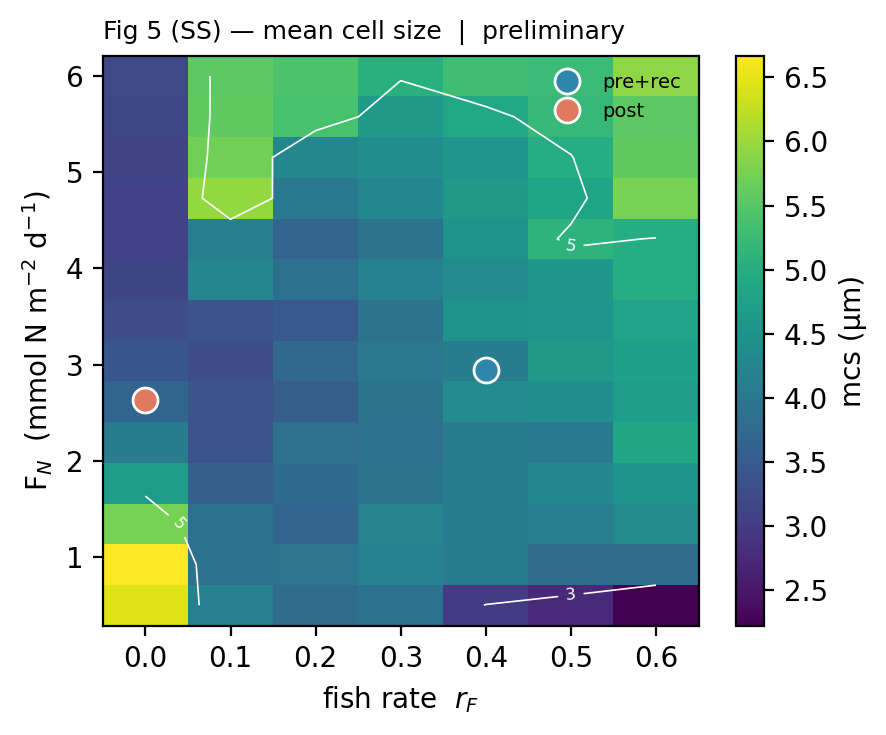


Monotonicity check:
  dMCS/dF_N > 0 in 54/91 edges (if mostly true → MCS rises with F_N)
  dMCS/dr_F > 0 in 58/84 edges (if mostly true → fish increases MCS)

Operating points (nearest grid):
  pre+rec ≈ (3.04, 0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025
  post     ≈ (2.62, 0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055
  pre/post MCS ratio: 1.11  (obs ≈ 7.66/3.28 = 2.33)


In [5]:
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd

# --- derive MCS and the other surfaces from tail-averaged state ---
# dims in scan are (FishGrazing__rate, Inflow__FN, time=1, [phyto|zoo])
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate').values
nFN, nRF = P.shape[:2]

W    = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)

bins = np.einsum('kp,ijp->ijk', W, P)               # (nFN, nRF, 3 Sieburth bins)
sb   = bins.sum(-1)                                  # ΣP-binned per cell
fr   = np.where(sb[..., None] > 0, bins / sb[..., None], np.nan)
MCS  = 10 ** (fr @ np.log10(GEOM))                  # (nFN, nRF)
PICO, NANO, MICRO = fr[..., 0], fr[..., 1], fr[..., 2]
SUMP = P.sum(-1)
SUMZ = Z.sum(-1)
Z200 = Z[..., zoo_esd > 200].sum(-1)
Z500 = Z[..., zoo_esd > 500].sum(-1)

print("Derived surfaces  (nFN x nRF):")
print(f"  MCS    min={np.nanmin(MCS):.2f}  max={np.nanmax(MCS):.2f}  µm")
print(f"  ΣP     min={np.nanmin(SUMP):.2f}  max={np.nanmax(SUMP):.2f}  mmol N m⁻³")
print(f"  ΣZ     min={np.nanmin(SUMZ):.2f}  max={np.nanmax(SUMZ):.2f}  mmol N m⁻³")
print(f"  Micro  min={np.nanmin(MICRO):.2f}  max={np.nanmax(MICRO):.2f}")
print(f"  Z>200  min={np.nanmin(Z200):.4f}  max={np.nanmax(Z200):.4f}  mmol N m⁻³")
print(f"  Z>500  min={np.nanmin(Z500):.4e}  max={np.nanmax(Z500):.4e}  mmol N m⁻³")
print(f"  N      min={np.nanmin(N):.2f}    max={np.nanmax(N):.2f}    mmol N m⁻³")

# --- quick-look MCS pcolormesh ---
fig, ax = plt.subplots(figsize=(4.6, 3.8))
pc = ax.pcolormesh(RF_VALUES, FN_VALUES, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(RF_VALUES, FN_VALUES, MCS, levels=[2, 3, 5, 8, 12, 20],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  $r_F$')
ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Fig 5 (SS) — mean cell size  |  preliminary', fontsize=9, loc='left')
fig.colorbar(pc, label='mcs (µm)')
ax.legend(fontsize=7, frameon=False, loc='upper right')
fig.tight_layout(); plt.show()

# --- sanity-check: monotonic in F_N? in r_F? cross-term curvature? ---
def _slope(arr, axis):
    return np.diff(arr, axis=axis)
dFN = _slope(MCS, axis=0)        # MCS change as F_N rises (along rows)
drF = _slope(MCS, axis=1)        # MCS change as r_F rises (along cols)
print(f"\nMonotonicity check:")
print(f"  dMCS/dF_N > 0 in {int(np.sum(dFN > 0))}/{dFN.size} edges "
      f"(if mostly true → MCS rises with F_N)")
print(f"  dMCS/dr_F > 0 in {int(np.sum(drF > 0))}/{drF.size} edges "
      f"(if mostly true → fish increases MCS)")
print(f"\nOperating points (nearest grid):")
i_pre, j_pre = int(np.argmin(np.abs(FN_VALUES - 2.94))), int(np.argmin(np.abs(RF_VALUES - 0.4)))
i_pos, j_pos = int(np.argmin(np.abs(FN_VALUES - 2.63))), int(np.argmin(np.abs(RF_VALUES - 0.0)))
print(f"  pre+rec ≈ ({FN_VALUES[i_pre]:.2f}, {RF_VALUES[j_pre]:.2f}): "
      f"MCS={MCS[i_pre,j_pre]:.2f} µm  Micro={MICRO[i_pre,j_pre]:.2f}  "
      f"Z>200={Z200[i_pre,j_pre]:.3f}")
print(f"  post     ≈ ({FN_VALUES[i_pos]:.2f}, {RF_VALUES[j_pos]:.2f}): "
      f"MCS={MCS[i_pos,j_pos]:.2f} µm  Micro={MICRO[i_pos,j_pos]:.2f}  "
      f"Z>200={Z200[i_pos,j_pos]:.3f}")
print(f"  pre/post MCS ratio: {MCS[i_pre,j_pre]/MCS[i_pos,j_pos]:.2f}  "
      f"(obs ≈ 7.66/3.28 = 2.33)")

In [6]:
import time as _t, numpy as np
from xso.parscans import run_xso_parscan

t0 = _t.perf_counter()
scan_loose = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',          # <-- default IVP_SOLVER_KWARGS
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,                            # reuse the same dict
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall (loose): {(_t.perf_counter()-t0)/60:.1f} min   "
      f"(tight was 4.6 min)\n")

# --- side-by-side: which cells differ? ---
P_loose = scan_loose['Phytoplankton__biomass'].squeeze('time').transpose(
    'Inflow__FN', 'FishGrazing__rate', 'phyto').values
nan_loose  = scan_loose['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
nan_tight  = scan['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_loose   = scan_loose['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_tight   = scan['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values

print("Trip count (tail_has_nan = True):")
print(f"  loose: {int(np.sum(nan_loose != 0))} / {nan_loose.size}")
print(f"  tight: {int(np.sum(nan_tight != 0))} / {nan_tight.size}")
print(f"\ncv_sumP (realised stability):")
print(f"  loose: max={np.nanmax(cv_loose):.4f}  >0.10 in {int(np.sum(cv_loose > 0.10))} cells")
print(f"  tight: max={np.nanmax(cv_tight):.4f}  >0.10 in {int(np.sum(cv_tight > 0.10))} cells")

# Compute MCS on both for direct comparison
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
def _mcs(P):
    b = np.einsum('kp,ijp->ijk', W, P); s = b.sum(-1)
    f = np.where(s[..., None] > 0, b / s[..., None], np.nan)
    return 10 ** (f @ np.log10(GEOM))

MCS_loose = _mcs(P_loose)
MCS_tight = _mcs(P)        # P from the previous (tight) scan, still in scope
diff = MCS_loose - MCS_tight
print(f"\nMCS_loose vs MCS_tight:")
print(f"  |Δ| max  = {np.nanmax(np.abs(diff)):.4f} µm")
print(f"  |Δ| mean = {np.nanmean(np.abs(diff)):.4f} µm")
print(f"  cells with |Δ| > 0.05 µm: {int(np.nansum(np.abs(diff) > 0.05))} / {diff.size}")
print(f"\nTrip cells in loose (i, j, F_N, r_F):")
trips_ij = np.argwhere(nan_loose != 0)
for i, j in trips_ij:
    print(f"  ({i:2d}, {j}) | F_N={FN_VALUES[i]:.2f}  r_F={RF_VALUES[j]:.2f}")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 57.92632 seconds.

wall (loose): 1.0 min   (tight was 4.6 min)

Trip count (tail_has_nan = True):
  loose: 14 / 98
  tight: 0 / 98

cv_sumP (realised stability):
  loose: max=0.0215  >0.10 in 0 cells
  tight: max=0.0216  >0.10 in 0 cells

MCS_loose vs MCS_tight:
  |Δ| max  = 0.2284 µm
  |Δ| mean = 0.0074 µm
  cells with |Δ| > 0.05 µm: 2 / 98

Trip cells in loose (i, j, F_N, r_F):
  ( 6, 4) | F_N=3.04  r_F=0.40
  ( 7, 4) | F_N=3.46  r_F=0.40
  ( 7, 5) | F_N=3.46  r_F=0.50
  ( 8, 5) | F_N=3.88  r_F=0.50
  ( 8, 6) | F_N=3.88  r_F=0.60
  ( 9, 5) | F_N=4.31  r_F=0.50
  ( 9, 6) | F_N=4.31  r_F=0.60
  (10, 5) | F_N=4.73  r_F=0.50
  (10, 6) | F_N=4.73  r_F=0.60
  (11, 5) | F_N=5.15  r_F=0.50
  (11, 6) | F_N=5.15  r_F=0.60
  (12, 5) | F_N=5.58  r_F=0.50
  (12, 6) | F_N=5.58  r_F=0.60
  (13, 6) | F_N=6.00  r_F=0.60


In [7]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')   # nfev projections

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

# TIGHT solver_kwargs (mirror what worked at SS); default neg floor (-1e-3)
SK_TIGHT = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
            'max_step': 1.0, 'instability_neg_threshold': -1e-3}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK_TIGHT),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy()
TRIPLOC_T = {}
def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    m = item['result']
    MCS[i,j]  = m.get('mcs_med', np.nan)
    CONV[i,j] = m.get('mcs_conv', np.nan)
    MINP[i,j] = m.get('minP', np.nan)
    MINZ[i,j] = m.get('minZ', np.nan)
    CVSP[i,j] = m.get('cv_sumP', np.nan)
    if m.get('has_nan'):
        fs, rf = combos[k]
        TRIPLOC_T[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'], label='fig5_seasonal_tight')

# --- diagnostics ---
n_trip = len(TRIPLOC_T)
n_tot  = MCS.size
print(f"\n--- TIGHT seasonal: trips {n_trip}/{n_tot}  (loose baseline was 21/49) ---\n")
if TRIPLOC_T:
    print("Trip cells still firing under tight tols:")
    for (i, j), (fs, rf, frac) in sorted(TRIPLOC_T.items(), key=lambda kv: (kv[1][0], kv[1][1])):
        print(f"  ({i:2d}, {j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
              f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
else:
    print("All cells completed without NaN-termination.")

# Stability picture of the converged cells
print(f"\ncv_sumP: max={np.nanmax(CVSP):.3f}  >0.10 in {int(np.nansum(CVSP > 0.10))} cells")
print(f"|conv-1|: max={np.nanmax(np.abs(CONV-1)):.3f}  >0.05 in {int(np.nansum(np.abs(CONV-1) > 0.05))} cells")
print(f"minP: min={np.nanmin(MINP):+.2e}  ({int(np.nansum(MINP < -1e-3))} cells < -1e-3)")
print(f"minZ: min={np.nanmin(MINZ):+.2e}  ({int(np.nansum(MINZ < -1e-3))} cells < -1e-3)")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_seasonal_tight) ---
   1/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.8m ETA 40.4m
   2/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 20.2m
   3/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 13.6m
   4/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 10.0m
   5/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 7.8m
   6/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 6.4m
   7/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 5.3m
   8/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.6m ETA 8.4m
   9/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 7.4m
  10/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 6.5m
  11/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.7m
  12/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.2m
  13/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 4.7m
  14/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.9m ETA 4.8m
  15/49 fig5_seasonal_tight | err=0 has_nan=0 | 2.4m ETA 5

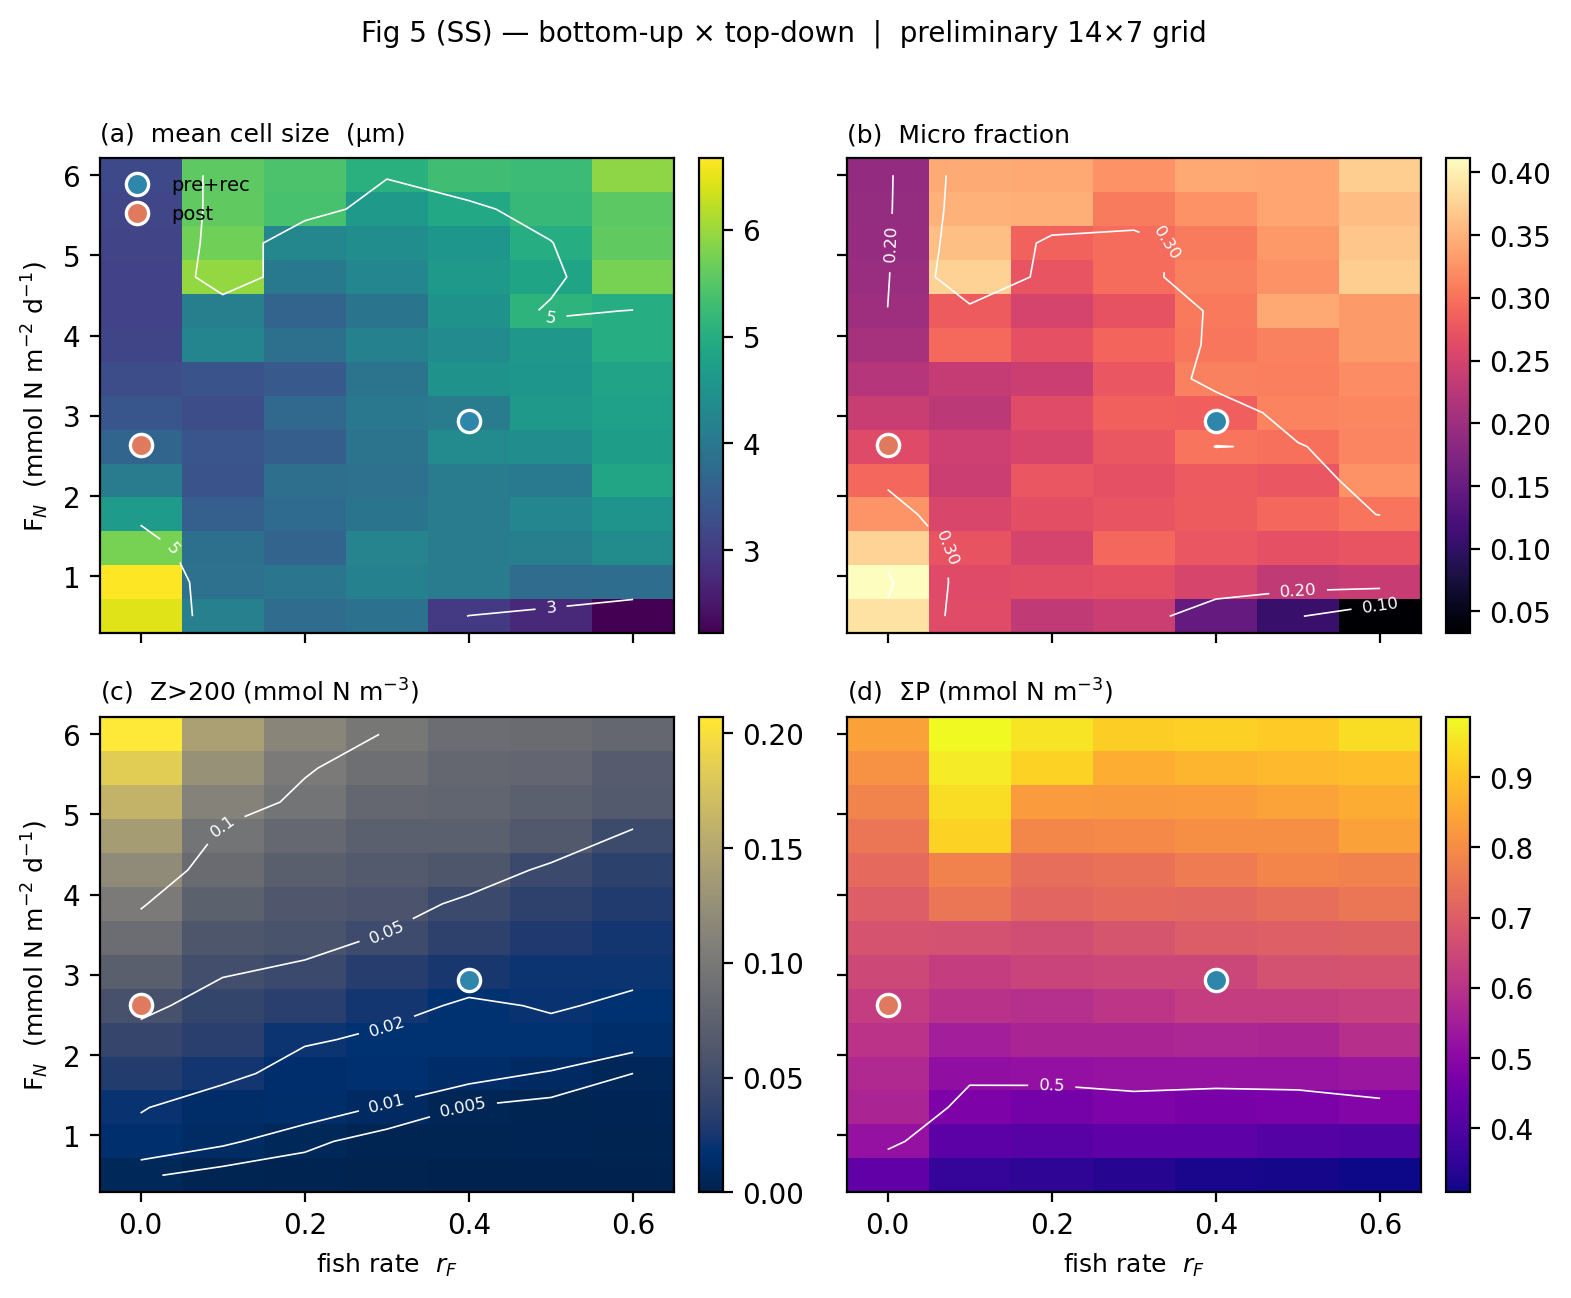

Operating points (nearest grid):
  pre+rec  ≈ (F_N=3.04, r_F=0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025  ΣP=0.65
  post     ≈ (F_N=2.62, r_F=0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055  ΣP=0.63

Monotonicity (positive-slope edge count):
  MCS   : dF_N>0 in  54/ 91  |  dr_F>0 in  58/ 84
  Micro : dF_N>0 in  52/ 91  |  dr_F>0 in  53/ 84
  Z>200 : dF_N>0 in  90/ 91  |  dr_F>0 in   9/ 84
  ΣP    : dF_N>0 in  91/ 91  |  dr_F>0 in  48/ 84


In [9]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd
from matplotlib.colors import LogNorm

# --- derive surfaces from the existing `scan` (tight SS) ---
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate').values
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = np.einsum('kp,ijp->ijk', W, P); sb = bins.sum(-1)
fr = np.where(sb[...,None]>0, bins/sb[...,None], np.nan)
MCS   = 10**(fr @ np.log10(GEOM))
MICRO = fr[...,2]
SUMP  = P.sum(-1); SUMZ = Z.sum(-1)
Z200  = Z[..., zoo_esd>200].sum(-1)

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'), ('post', 2.63, 0.0, '#E07A5F')]

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.6), sharex=True, sharey=True)
panels = [
    ('(a)  mean cell size  (µm)',  MCS,  'viridis',  [2,3,5,8,12,20], '%g',  None),
    ('(b)  Micro fraction',        MICRO,'magma',    [0.1,0.2,0.3,0.4,0.5,0.6], '%.2f', None),
    ('(c)  Z>200 (mmol N m$^{-3}$)', Z200,'cividis', [0.005,0.01,0.02,0.05,0.1], '%.3g', None),
    ('(d)  ΣP (mmol N m$^{-3}$)',  SUMP, 'plasma',   [0.2,0.5,1.0,2.0,4.0],  '%.2g', None),
]
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(RF_VALUES, FN_VALUES, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(RF_VALUES, FN_VALUES, surf, levels=lvls, colors='white', linewidths=0.6)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
axes[0,0].legend(fontsize=7, frameon=False, loc='upper left')
for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (SS) — bottom-up × top-down  |  preliminary 14×7 grid', fontsize=10)
fig.tight_layout(rect=(0,0,1,0.97)); plt.show()

# --- read-off: operating-point numbers + monotonicity ---
print("Operating points (nearest grid):")
for lbl, fn, rf, _ in OPS:
    i, j = int(np.argmin(np.abs(FN_VALUES - fn))), int(np.argmin(np.abs(RF_VALUES - rf)))
    print(f"  {lbl:8s} ≈ (F_N={FN_VALUES[i]:.2f}, r_F={RF_VALUES[j]:.2f}): "
          f"MCS={MCS[i,j]:.2f} µm  Micro={MICRO[i,j]:.2f}  Z>200={Z200[i,j]:.3f}  ΣP={SUMP[i,j]:.2f}")
def _mono(a, ax): return int(np.sum(np.diff(a, axis=ax) > 0))
print(f"\nMonotonicity (positive-slope edge count):")
for name, surf in [('MCS', MCS), ('Micro', MICRO), ('Z>200', Z200), ('ΣP', SUMP)]:
    print(f"  {name:6s}: dF_N>0 in {_mono(surf,0):3d}/{(surf.shape[0]-1)*surf.shape[1]:3d}  |  "
          f"dr_F>0 in {_mono(surf,1):3d}/{surf.shape[0]*(surf.shape[1]-1):3d}")

In [3]:
import time as _t, numpy as np, os
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

FN_HI = np.linspace(0.5, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
spec  = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de': 50.0, 'Temperature__value': 20.0,
    'Growth__mu_max': spec['mu_max'], 'Growth__halfsat': spec['halfsat'],
    'PhytoMortality__rate': 0.0015, 'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ': 0.23, 'Grazing__sigma_log': 0.20, 'GrazingRouter__gge': 0.31,
}

t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min")

# Save to netCDF — figure can be re-rendered from this without re-running
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_28x13_2026-06-24.nc')
# arrays in fixed_overrides are stored as object dtype in xarray; drop those
# from the saved dataset (they're recoverable from the construct spec, and
# netCDF doesn't serialize them cleanly)
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars
                              if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0, forcing='SS, decoupled (T=T_REF, de=DE_DEFAULT)',
    solver='setup_baseline_slim_tight (atol=1e-9, rtol=1e-6, max_step=1.0)',
    created='2026-06-24',
))
to_save.to_netcdf(nc_path)
print(f"saved: {nc_path}  ({os.path.getsize(nc_path)/1e6:.1f} MB)")
print(f"  reload with: scan_hi = xarray.open_dataset('{nc_path}')")
print(f"  trips: {int(scan_hi['tail_has_nan'].sum().item())}/{scan_hi['tail_has_nan'].size}")
print(f"  cv_sumP max: {float(scan_hi['cv_sumP'].max().item()):.4f}")

PROGRESS: Completed 14/50 outer points. (Inflow__FN = 1.9591836734693877).


Process SpawnPoolWorker-6:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-3:


KeyboardInterrupt: 

In [11]:
import warnings, numpy as np, time as _t
import seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

# pick the cell that was running hardest under RK45-tight
i_hi, j_hi = np.unravel_index(np.nanargmax(CVSP), CVSP.shape)
fs_hi, rf_hi = float(FN_SCALE[i_hi]), float(R_F[j_hi])
mean_fn_hi = base['fn'].mean() * fs_hi
mcs_rk45 = MCS[i_hi, j_hi]; cv_rk45 = CVSP[i_hi, j_hi]; conv_rk45 = CONV[i_hi, j_hi]
print(f"Target cell (max cv_sumP under RK45-tight):")
print(f"  (i, j) = ({i_hi}, {j_hi})  | F_N×{fs_hi:.3f} (mean {mean_fn_hi:.2f})  r_F={rf_hi:.2f}")
print(f"  RK45-tight: mcs_med={mcs_rk45:.3f} µm  cv_sumP={cv_rk45:.3f}  conv={conv_rk45:.4f}\n")

SK_DOP = {'method': 'DOP853', 'atol': 1e-9, 'rtol': 1e-6,
          'max_step': 1.0, 'instability_neg_threshold': -1e-3}
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}

t0 = _t.perf_counter()
clim_dop = ssh.run_one(construct=spec,
                       forcing={**base, 'fn': base['fn'] * fs_hi},
                       fish_rate=rf_hi, years=40, spinup=10,
                       mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                       solver_kwargs=SK_DOP)
wall = _t.perf_counter() - t0
print(f"DOP853 wall: {wall:.1f} s\n")

mcs_dop  = clim_dop.get('mcs_med', np.nan)
cv_dop   = clim_dop.get('cv_sumP', np.nan)
conv_dop = clim_dop.get('mcs_conv', np.nan)
minP_dop = clim_dop.get('minP', np.nan)
print(f"DOP853:    mcs_med={mcs_dop:.3f} µm  cv_sumP={cv_dop:.3f}  conv={conv_dop:.4f}  "
      f"has_nan={clim_dop.get('has_nan')}  minP={minP_dop:+.2e}")
print(f"\nΔ vs RK45-tight:")
print(f"  Δmcs    = {mcs_dop - mcs_rk45:+.4f} µm  ({abs(mcs_dop-mcs_rk45)/max(mcs_rk45,1e-12)*100:.2f} %)")
print(f"  Δcv_sumP = {cv_dop - cv_rk45:+.4f}   ({abs(cv_dop-cv_rk45)/max(cv_rk45,1e-12)*100:.2f} %)")
print(f"  Δconv   = {conv_dop - conv_rk45:+.4f}")

Target cell (max cv_sumP under RK45-tight):
  (i, j) = (6, 2)  | F_N×1.700 (mean 5.22)  r_F=0.20
  RK45-tight: mcs_med=3.704 µm  cv_sumP=1.380  conv=0.8656

DOP853 wall: 67.0 s

DOP853:    mcs_med=nan µm  cv_sumP=nan  conv=nan  has_nan=True  minP=+nan

Δ vs RK45-tight:
  Δmcs    = +nan µm  (nan %)
  Δcv_sumP = +nan   (nan %)
  Δconv   = +nan


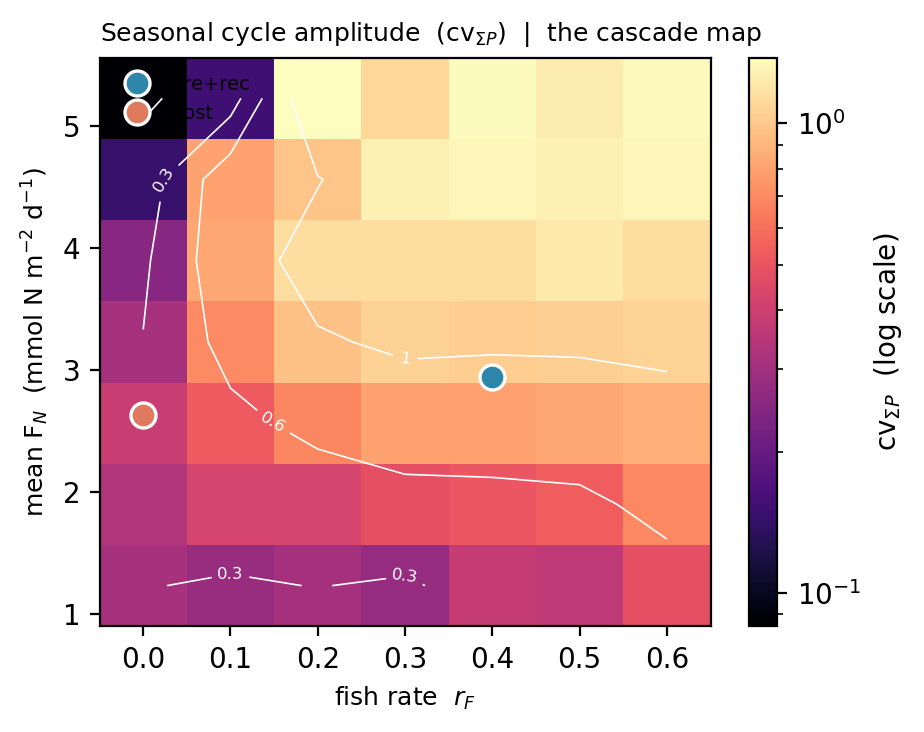

cv_sumP at the era operating points (nearest grid):
  pre+rec  ≈ (F_N=3.23, r_F=0.40): cv_sumP=1.038  mcs_med=4.07 µm
  post     ≈ (F_N=2.56, r_F=0.00): cv_sumP=0.390  mcs_med=5.75 µm

cv_sumP range across the plane: 0.085 – 1.380
highest-cv cell: (F_N=5.22, r_F=0.20)  cv=1.380

Correlation of cv_sumP with mcs_med across the plane:


ValueError: operands could not be broadcast together with shapes (7,7) (14,7) 

In [12]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mean_FN = base['fn'].mean() * FN_SCALE

fig, ax = plt.subplots(figsize=(4.8, 3.8))
pc = ax.pcolormesh(R_F, mean_FN, CVSP, shading='nearest', cmap='magma',
                   norm=LogNorm(vmin=max(np.nanmin(CVSP), 1e-3), vmax=np.nanmax(CVSP)))
cs = ax.contour(R_F, mean_FN, CVSP, levels=[0.05, 0.1, 0.3, 0.6, 1.0],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%.2g')

# era operating points
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', mew=1.2, label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', mew=1.2, label='post')

ax.set_xlabel('fish rate  $r_F$', fontsize=9)
ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
ax.set_title('Seasonal cycle amplitude  (cv$_{\\Sigma P}$)  |  the cascade map',
             fontsize=9, loc='left')
ax.legend(fontsize=7, frameon=False, loc='upper left')
cb = fig.colorbar(pc, label=r'cv$_{\Sigma P}$  (log scale)')
fig.tight_layout(); plt.show()

# numerical read-off
print("cv_sumP at the era operating points (nearest grid):")
for lbl, fn, rf in [('pre+rec', 2.94, 0.4), ('post', 2.63, 0.0)]:
    i = int(np.argmin(np.abs(mean_FN - fn)))
    j = int(np.argmin(np.abs(R_F - rf)))
    print(f"  {lbl:8s} ≈ (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}): "
          f"cv_sumP={CVSP[i,j]:.3f}  mcs_med={MCS[i,j]:.2f} µm")
print(f"\ncv_sumP range across the plane: {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"highest-cv cell: (F_N={mean_FN[i_hi]:.2f}, r_F={R_F[j_hi]:.2f})  cv={CVSP[i_hi,j_hi]:.3f}")
print(f"\nCorrelation of cv_sumP with mcs_med across the plane:")
ok = np.isfinite(CVSP) & np.isfinite(MCS)
r = np.corrcoef(CVSP[ok], MCS[ok])[0,1]
print(f"  r = {r:+.3f}  (positive → bigger cycles ↔ bigger time-mean cells, the cascade-as-amplitude reading)")

Marañón peak: P[19] s = 5.79 µm (μ_max = 0.830 d⁻¹)

default    wall 47.6s  reached t = 19995 d
all-Pico   wall 49.8s  reached t = 19995 d
all-peak   wall 48.0s  reached t = 19995 d


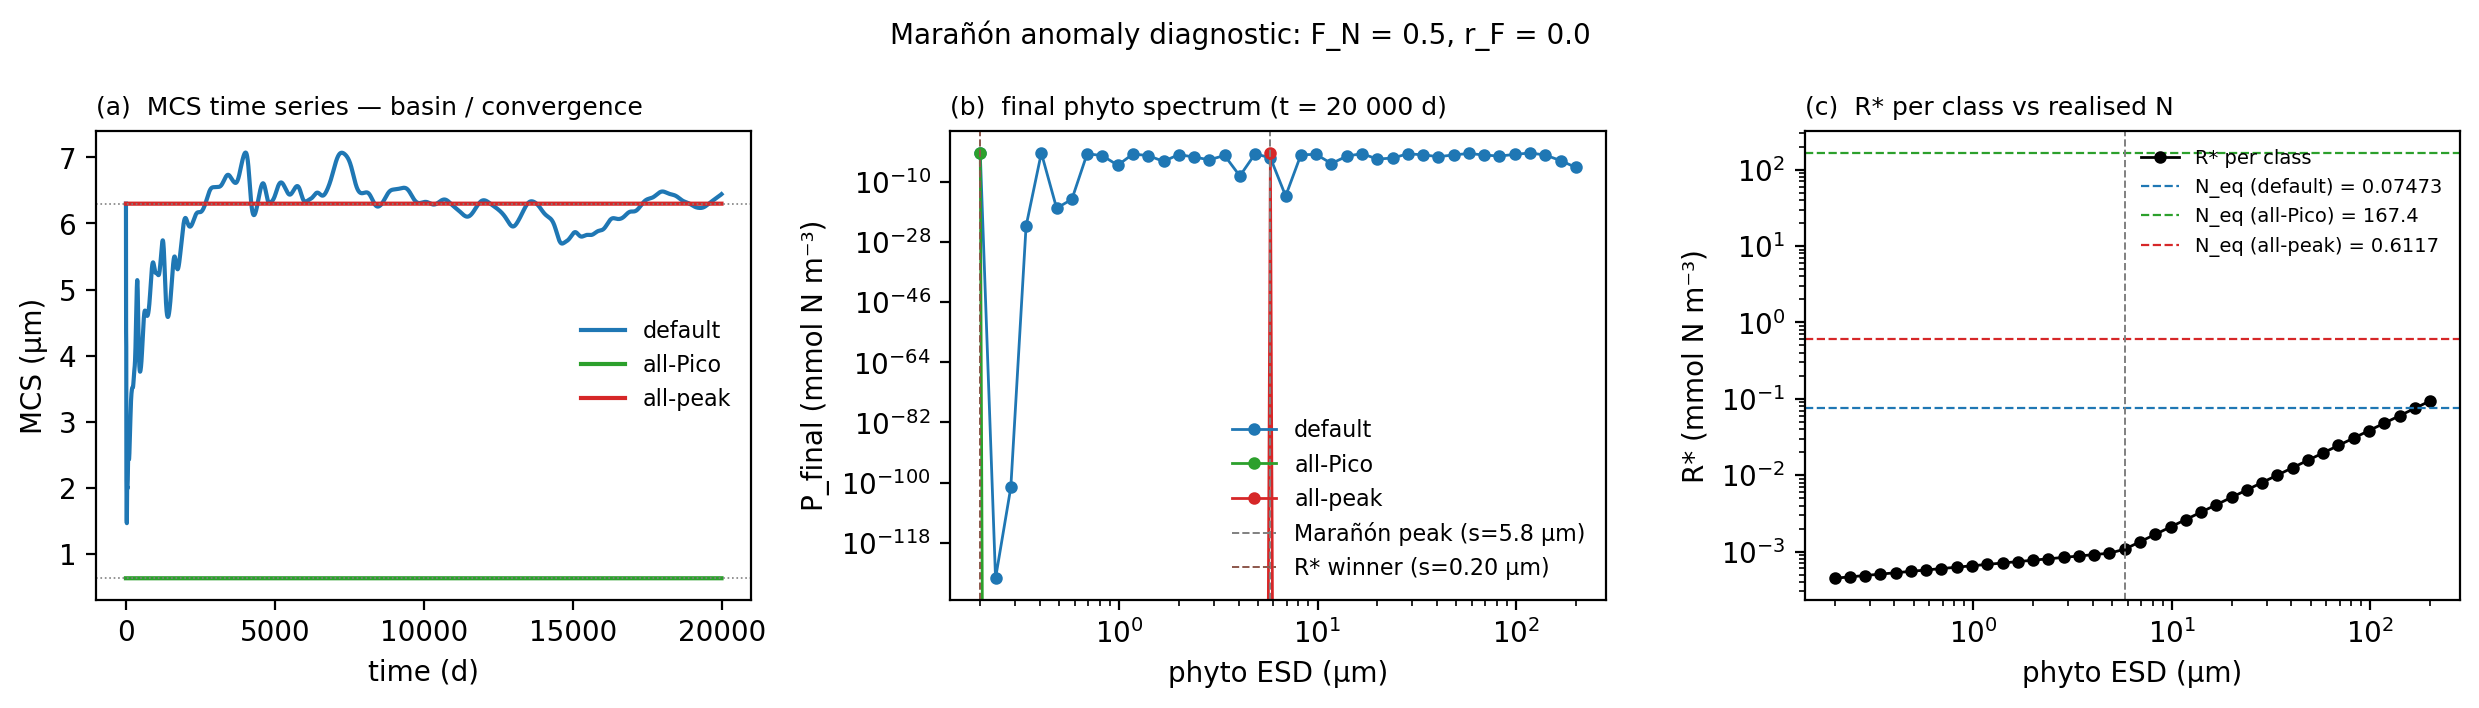


Theoretical R* winner: P[0]  s = 0.20 µm  R* = 4.4682e-04
R* at Marañón peak  P[19]: 1.0730e-03

default   : MCS_final =  6.44 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0518  |  N_eq = 0.0747
all-Pico  : MCS_final =  0.63 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0305  |  N_eq = 167.4273
all-peak  : MCS_final =  6.30 µm  |  dominant = P[19] s= 5.79 µm  |  P_dom = 0.0571  |  N_eq = 0.6117

--- verdict ---
MCS spread across ICs = 5.81 µm → MULTIPLE BASINS confirmed.
→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC
  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.


In [13]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np, matplotlib.pyplot as plt
import xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    phyto_esd, phyto_init,
)

# --- anomaly cell: lowest F_N + zero fish ---
FN0, RF0, DE0, T0 = 0.5, 0.0, 50.0, 20.0
spec = ssh.allometry('maranon_ward')
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']
P_total_init = float(np.sum(phyto_init))
i_peak = int(np.argmax(mu_max_arr))   # Marañón peak class
print(f"Marañón peak: P[{i_peak}] s = {phyto_esd[i_peak]:.2f} µm "
      f"(μ_max = {mu_max_arr[i_peak]:.3f} d⁻¹)\n")

# --- three initial conditions ---
ic_default = phyto_init.copy()
ic_all_pico = np.zeros_like(phyto_init); ic_all_pico[0]     = P_total_init
ic_all_peak = np.zeros_like(phyto_init); ic_all_peak[i_peak] = P_total_init
ic_variants = {'default':   ic_default,
               'all-Pico':  ic_all_pico,
               'all-peak':  ic_all_peak}

# --- long IVP, 20000 d, tight tols, coarsened t_eval (5-d) ---
T_END   = 20000.0
time_ax = np.arange(0.0, T_END, 5.0)
SK = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
      'max_step': 1.0, 'instability_neg_threshold': -1e-3}

results = {}
for label, ic in ic_variants.items():
    iv = make_baseline_input_vars(
        fish_rate=RF0, FN=FN0, de=DE0, T=T0,
        mu_max=mu_max_arr, halfsat=ks_arr, mP=0.0015, m_Z=0.1,
    )
    iv['Phytoplankton']['biomass_init'] = ic
    iv['Grazing']['KsZ']       = 0.23
    iv['Grazing']['sigma_log'] = 0.20
    iv['GrazingRouter']['gge'] = 0.31
    setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                      input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=SK)
    t0 = _t.perf_counter()
    out = pue.run_single_point(model_baseline, setup, {})
    print(f"{label:10s} wall {_t.perf_counter()-t0:.1f}s  "
          f"reached t = {out['time'].values[-1]:.0f} d")
    results[label] = out

# --- derived series ---
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
W    = pue.compute_sieburth_weights(phyto_esd)

# --- theoretical R* per class (at T_REF, Q10 factor = 1) ---
mP = 0.0015
R_star = mP * ks_arr / np.maximum(mu_max_arr - mP, 1e-12)
i_R_winner = int(np.argmin(R_star))

# --- 3-panel diagnostic plot ---
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
colors = {'default': 'C0', 'all-Pico': 'C2', 'all-peak': 'C3'}

for label, out in results.items():
    P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
    t = out['time'].values
    bins = W @ P; sb = bins.sum(0)
    fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
    mcs = 10 ** (np.log10(GEOM) @ fr)
    axes[0].plot(t, mcs, lw=1.5, color=colors[label], label=label)
    # final spectrum
    axes[1].plot(phyto_esd, P[:, -1], 'o-', ms=3.5, lw=1.0,
                 color=colors[label], label=label)

axes[0].set_xlabel('time (d)'); axes[0].set_ylabel('MCS (µm)')
axes[0].set_title('(a)  MCS time series — basin / convergence', fontsize=9, loc='left')
axes[0].axhline(0.63, color='0.5', ls=':', lw=0.6); axes[0].axhline(6.3, color='0.5', ls=':', lw=0.6)
axes[0].legend(fontsize=8, frameon=False)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('phyto ESD (µm)'); axes[1].set_ylabel('P_final (mmol N m⁻³)')
axes[1].set_title('(b)  final phyto spectrum (t = 20 000 d)', fontsize=9, loc='left')
axes[1].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7,
                label=f'Marañón peak (s={phyto_esd[i_peak]:.1f} µm)')
axes[1].axvline(phyto_esd[i_R_winner], color='C5', ls='--', lw=0.7,
                label=f'R* winner (s={phyto_esd[i_R_winner]:.2f} µm)')
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(phyto_esd, R_star, 'o-', ms=3.5, lw=1.0, color='k', label='R* per class')
for label, out in results.items():
    N_eq = float(out['Nutrient__value'].values[-1])
    axes[2].axhline(N_eq, color=colors[label], ls='--', lw=0.8,
                    label=f'N_eq ({label}) = {N_eq:.4g}')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('phyto ESD (µm)'); axes[2].set_ylabel('R* (mmol N m⁻³)')
axes[2].set_title('(c)  R* per class vs realised N', fontsize=9, loc='left')
axes[2].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7)
axes[2].legend(fontsize=7, frameon=False)

fig.suptitle(f'Marañón anomaly diagnostic: F_N = {FN0}, r_F = {RF0}', fontsize=10)
fig.tight_layout(); plt.show()

# --- numeric read-off + verdict ---
print(f"\nTheoretical R* winner: P[{i_R_winner}]  s = {phyto_esd[i_R_winner]:.2f} µm  "
      f"R* = {R_star[i_R_winner]:.4e}")
print(f"R* at Marañón peak  P[{i_peak}]: {R_star[i_peak]:.4e}\n")
mcs_finals = {}
for label, out in results.items():
    P_final = out['Phytoplankton__biomass'].transpose('phyto', 'time').values[:, -1]
    N_eq    = float(out['Nutrient__value'].values[-1])
    i_dom   = int(np.argmax(P_final))
    bins    = W @ P_final.reshape(-1, 1)
    fr      = bins / max(bins.sum(), 1e-12)
    mcs_f   = float(10 ** (np.log10(GEOM) @ fr.flatten()))
    mcs_finals[label] = mcs_f
    print(f"{label:10s}: MCS_final = {mcs_f:5.2f} µm  |  dominant = P[{i_dom}] "
          f"s={phyto_esd[i_dom]:5.2f} µm  |  P_dom = {P_final[i_dom]:.4f}  |  N_eq = {N_eq:.4f}")

print("\n--- verdict ---")
spread = max(mcs_finals.values()) - min(mcs_finals.values())
if spread > 0.5:
    print(f"MCS spread across ICs = {spread:.2f} µm → MULTIPLE BASINS confirmed.")
    print("→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC")
    print("  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.")
else:
    print(f"MCS spread across ICs = {spread:.2f} µm → SINGLE ATTRACTOR.")
    print("→ All ICs converge to the same state. Either Marañón unimodal μ truly")
    print("  selects the peak class at low N (check whether realised N stays above")
    print("  the R*-winner's break-even on (c)), or 20000 d is still too short.")

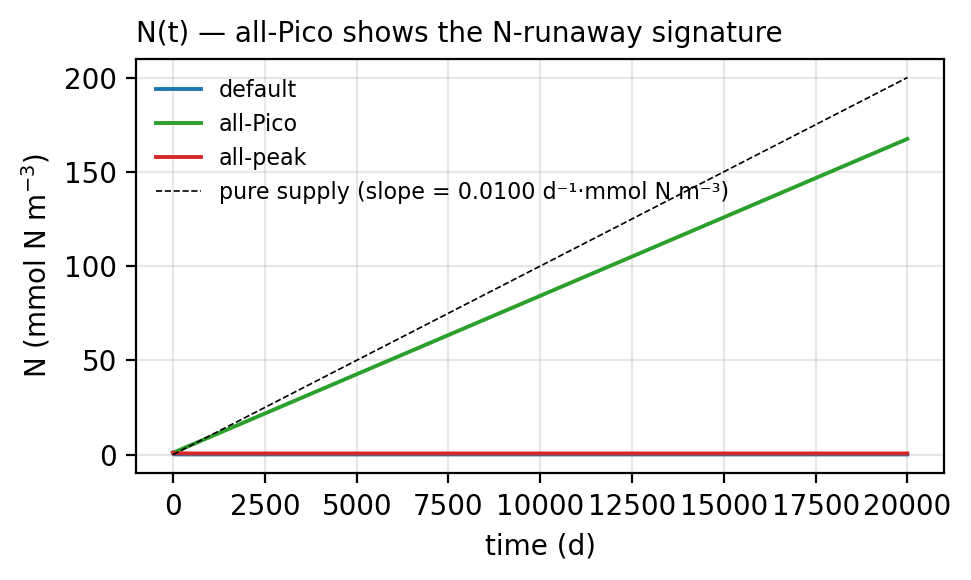

N final values: default=0.075, all-Pico=167.427, all-peak=0.612
Pure-supply N(t=20000) would be: 200.000


In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
for label, out in results.items():
    ax.plot(out['time'].values, out['Nutrient__value'].values, lw=1.4,
            color={'default':'C0','all-Pico':'C2','all-peak':'C3'}[label], label=label)
ax.set_xlabel('time (d)'); ax.set_ylabel('N (mmol N m$^{-3}$)')
ax.set_title('N(t) — all-Pico shows the N-runaway signature', fontsize=10, loc='left')
# annotate the supply rate
supply = 0.5 / 50.0    # F_N / d_e
ax.plot([0, 20000], [0, supply*20000], 'k--', lw=0.6,
        label=f'pure supply (slope = {supply:.4f} d⁻¹·mmol N m⁻³)')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"N final values: default={results['default']['Nutrient__value'].values[-1]:.3f}, "
      f"all-Pico={results['all-Pico']['Nutrient__value'].values[-1]:.3f}, "
      f"all-peak={results['all-peak']['Nutrient__value'].values[-1]:.3f}")
print(f"Pure-supply N(t=20000) would be: {supply*20000:.3f}")

In [ ]:
import time as _t, numpy as np, os
import xarray as xr
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

# --- high-res axes; F_N extended down to 0.1 to capture low-N anomaly ---
FN_HI = np.linspace(0.1, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
print(f"axes: F_N {FN_HI[0]:.2f}–{FN_HI[-1]:.2f} (Δ={FN_HI[1]-FN_HI[0]:.3f}, n={len(FN_HI)})  |  "
      f"r_F {RF_HI[0]:.2f}–{RF_HI[-1]:.2f} (Δ={RF_HI[1]-RF_HI[0]:.4f}, n={len(RF_HI)})")
print(f"cells: {len(FN_HI)*len(RF_HI)} = 2500\n")

# --- construct overrides (same as the 14×7 preview + smoke test) ---
spec = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de':             50.0,
    'Temperature__value':     20.0,
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

# --- run ---
t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,        # Mac Studio: bump to physical core count if desired
)
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min")

# --- summary ---
n_trip = int(scan_hi['tail_has_nan'].sum().item())
cv_max = float(scan_hi['cv_sumP'].max().item())
n_size = int(scan_hi['cv_sumP'].size)
print(f"trips: {n_trip}/{n_size}  |  cv_sumP max: {cv_max:.4f}  "
      f"(>0.10 in {int((scan_hi['cv_sumP'] > 0.10).sum().item())} cells)")

# --- save to netCDF; drop object-dtype vars (the constant arrays from fixed_overrides) ---
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_50x50_2026-06-24.nc')
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0,
    forcing='SS, decoupled (T = T_REF = 20°C → Q10 factor = 1; de = 50 m)',
    solver='setup_baseline_slim_tight (RK45, atol=1e-9, rtol=1e-6, max_step=1.0)',
    FN_range='linear 0.1–6.0, 50 pts (extended down to 0.1 to portrait low-N anomaly)',
    rF_range='linear 0.0–0.6, 50 pts',
    created='2026-06-24',
    notes='2500-cell SS map for Fig 5; see project_solver_tolerances.md and the '
          '"Cycle-Boundary Approach" entry in Ideas and Findings.md for the solver '
          'and dynamical-regime context.',
))
to_save.to_netcdf(nc_path)
size_mb = os.path.getsize(nc_path) / 1e6
print(f"\nsaved: {nc_path}  ({size_mb:.1f} MB)")
print(f"reload later with: scan_hi = xr.open_dataset('{nc_path}')")